# Notebook 06 — Robustness, Drift & Stress Testing
**DNSC 6330 Capstone | HMDA LAR 2024**

**Structure:**
- Part A: Distribution Drift (PSI, KS, MMD)
- Part B: Generalization Gap & Spurious Correlations
- Part C: Robustness & Stress Testing (Slices, Scenarios, ICE)

> **Key principle :** A model that performs well on a test set is not necessarily robust. Responsible deployment requires evidence of stability under shift, stress, and subgroup variation.

## 0. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

import os

# ── Paths ────────────────────────────────────────────────────────────────────
BASE_DIR    = os.getcwd()
FIGURES_DIR = os.path.join(BASE_DIR, 'figures')
TABLES_DIR  = os.path.join(BASE_DIR, 'tables')
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(TABLES_DIR,  exist_ok=True)

from scipy.stats import ks_2samp
from sklearn.metrics import (
    roc_auc_score, accuracy_score, log_loss,
    f1_score, brier_score_loss
)
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 4)

print('Imports OK')
print(f'BASE_DIR:    {BASE_DIR}')
print(f'FIGURES_DIR: {FIGURES_DIR}')
print(f'TABLES_DIR:  {TABLES_DIR}')

Imports OK
BASE_DIR:    /Users/zuleirys/Desktop/Responsible Machine Learning/Final Project/Code
FIGURES_DIR: /Users/zuleirys/Desktop/Responsible Machine Learning/Final Project/Code/figures
TABLES_DIR:  /Users/zuleirys/Desktop/Responsible Machine Learning/Final Project/Code/tables


## 0.1 Load Artifacts

In [2]:
X_train    = pd.read_parquet(os.path.join(BASE_DIR, 'X_train_imputed.parquet'))
X_test     = pd.read_parquet(os.path.join(BASE_DIR, 'X_test_imputed.parquet'))
y_train    = pd.read_parquet(os.path.join(BASE_DIR, 'y_train.parquet')).squeeze()
y_test     = pd.read_parquet(os.path.join(BASE_DIR, 'y_test.parquet')).squeeze()
prot_train = pd.read_parquet(os.path.join(BASE_DIR, 'prot_train.parquet'))
prot_test  = pd.read_parquet(os.path.join(BASE_DIR, 'prot_test.parquet'))

model = joblib.load(os.path.join(BASE_DIR, 'best_model.pkl'))
with open(os.path.join(BASE_DIR, 'model_meta.json')) as f:
    meta = json.load(f)
with open(os.path.join(BASE_DIR, 'threshold_meta.json')) as f:
    threshold_meta = json.load(f)

THRESHOLD = float(threshold_meta['global_threshold'])
GROUP_THRESHOLDS = threshold_meta.get('group_thresholds', {})

expected_cols = meta.get('feature_columns', [])
if expected_cols:
    X_train = X_train[expected_cols]
    X_test = X_test[expected_cols]
    print(f'Feature alignment OK — {len(expected_cols)} columns')

X_train_filled = X_train.copy()
X_test_filled = X_test.copy()

from sklearn.utils import resample
MAX_ROWS = 500_000
if len(X_train_filled) > MAX_ROWS:
    idx = resample(
        np.arange(len(X_train_filled)),
        replace=False,
        n_samples=MAX_ROWS,
        stratify=y_train,
        random_state=42,
    )
    idx = np.sort(idx)
    X_train_filled = X_train_filled.iloc[idx].reset_index(drop=True)
    y_train = y_train.iloc[idx].reset_index(drop=True)
    prot_train = prot_train.iloc[idx].reset_index(drop=True)
    print(f'Train capped at {MAX_ROWS:,} rows for this notebook')

print(f'X_train: {X_train_filled.shape} | X_test: {X_test_filled.shape}')
print(f'Train approval rate: {y_train.mean():.2%}')
print(f'Test approval rate:  {y_test.mean():.2%}')


def apply_threshold_policy(y_prob, groups, global_threshold, group_thresholds=None):
    groups = pd.Series(groups).fillna('Unknown').astype(str)
    thresholds = groups.map(group_thresholds or {}).fillna(global_threshold).astype(float)
    return (np.array(y_prob) >= thresholds.to_numpy()).astype(int)

Feature alignment OK — 21 columns


Train capped at 500,000 rows for this notebook
X_train: (500000, 21) | X_test: (1732355, 21)
Train approval rate: 75.72%
Test approval rate:  75.72%


---
## Part A: Distribution Drift

> - **PSI** — binned distribution comparison (eq. 4.1)
> - **KS test** — nonparametric two-sample test on CDFs (eq. 4.2)
> - **MMD** — kernel-based test for high-dimensional feature space (eq. 4.3)
>
> PSI/KS are **leading indicators**. Rolling AUC is a **lagging indicator** (Lecture 04, slide 24).

### A1. Population Stability Index (PSI)
$$\text{PSI} = \sum_{k=1}^{K} (p^{tr}_k - p^{dep}_k) \ln\left(\frac{p^{tr}_k}{p^{dep}_k}\right)$$

Thresholds: PSI < 0.10 → stable; 0.10–0.25 → monitor; > 0.25 → retrain

In [3]:
def compute_psi(expected, actual, bins=10):
    expected = np.array(expected).flatten()
    actual   = np.array(actual).flatten()
    expected = expected[~np.isnan(expected)]
    actual   = actual[~np.isnan(actual)]
    breakpoints = np.quantile(expected, np.linspace(0, 1, bins + 1))
    breakpoints = np.unique(breakpoints)
    expected_pcts = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    actual_pcts   = np.histogram(actual,   bins=breakpoints)[0] / len(actual)
    expected_pcts = np.where(expected_pcts == 0, 1e-6, expected_pcts)
    actual_pcts   = np.where(actual_pcts   == 0, 1e-6, actual_pcts)
    return np.sum((expected_pcts - actual_pcts) * np.log(expected_pcts / actual_pcts))


def psi_flag(val):
    if val < 0.10:   return 'STABLE'
    elif val < 0.25: return 'MONITOR'
    else:            return 'RETRAIN'


numeric_features = X_train.select_dtypes(include='number').columns.tolist()

psi_results = []
for col in numeric_features:
    psi_val = compute_psi(X_train[col], X_test[col])
    psi_results.append({
        'feature': col,
        'PSI':     round(psi_val, 4),
        'status':  psi_flag(psi_val)
    })

psi_df = pd.DataFrame(psi_results).sort_values('PSI', ascending=False)
print('── PSI Results ──')
print(psi_df.to_string(index=False))

── PSI Results ──
                      feature  PSI status
                       income  0.0 STABLE
         debt_to_income_ratio  0.0 STABLE
               property_value  0.0 STABLE
             has_credit_score  0.0 STABLE
co_applicant_has_credit_score  0.0 STABLE


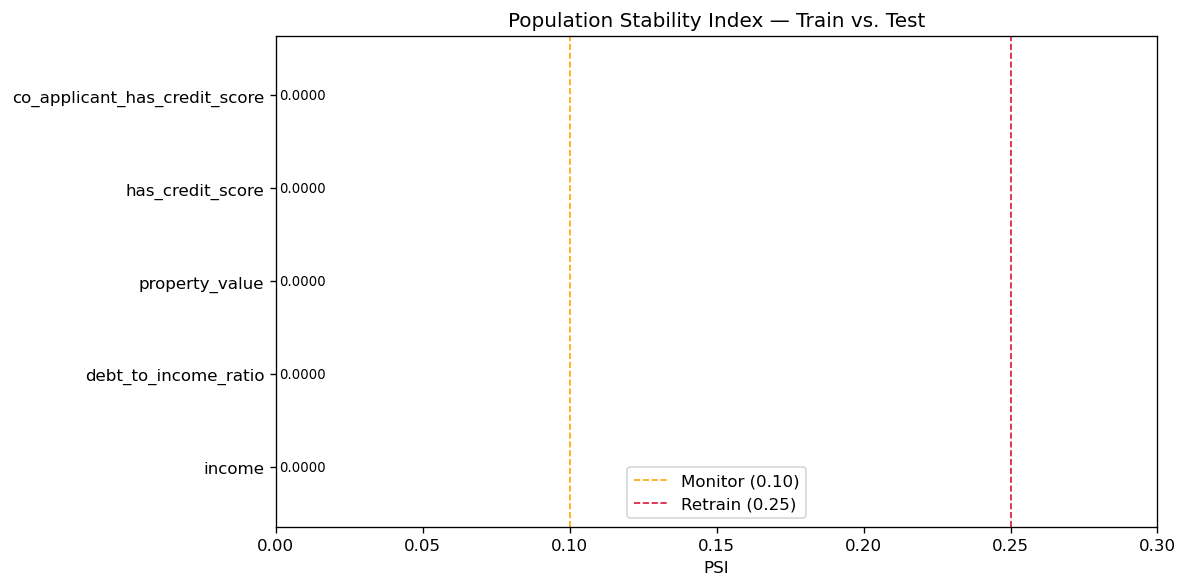

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = psi_df['status'].map({'STABLE': 'steelblue', 'MONITOR': 'orange', 'RETRAIN': 'crimson'})
bars = ax.barh(psi_df['feature'], psi_df['PSI'], color=colors)

# Add value labels so near-zero bars are still readable
for bar, val in zip(bars, psi_df['PSI']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=8)

ax.axvline(0.10, color='orange', linestyle='--', linewidth=1, label='Monitor (0.10)')
ax.axvline(0.25, color='crimson', linestyle='--', linewidth=1, label='Retrain (0.25)')

# Scale x-axis to show bars even when all PSI values are near zero
x_max = max(psi_df['PSI'].max() * 1.5, 0.30)
ax.set_xlim(0, x_max)

ax.set_xlabel('PSI')
ax.set_title('Population Stability Index — Train vs. Test')
ax.legend()
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'A1_psi.png'))
plt.show()

### A2. Kolmogorov–Smirnov (KS) Test
$$D = \sup_x |F_1(x) - F_2(x)|$$

In [5]:
ks_results = []
for col in numeric_features:
    train_vals = X_train[col].dropna()
    test_vals  = X_test[col].dropna()
    stat, pval = ks_2samp(train_vals, test_vals)
    ks_results.append({
        'feature': col,
        'KS_stat': round(stat, 4),
        'p_value': round(pval, 4),
        'sig':     '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else ''))
    })

ks_df = pd.DataFrame(ks_results).sort_values('KS_stat', ascending=False)
print('── KS Test Results ──')
print(ks_df.to_string(index=False))
print('\n* p<0.05  ** p<0.01  *** p<0.001')

── KS Test Results ──
                      feature  KS_stat  p_value sig
         debt_to_income_ratio   0.0006   0.6484    
               property_value   0.0006   0.6479    
                       income   0.0005   0.9368    
co_applicant_has_credit_score   0.0001   1.0000    
             has_credit_score   0.0000   1.0000    

* p<0.05  ** p<0.01  *** p<0.001


### A3. Maximum Mean Discrepancy (MMD)
$$\text{MMD}^2(X,Y) = \frac{1}{m(m-1)}\sum_{i}\sum_{j\ne i} k(x_i,x_j) - \frac{2}{m^2}\sum_i\sum_j k(x_i,y_j) + \frac{1}{m(m-1)}\sum_i\sum_{j\ne i} k(y_i,y_j)$$

In [6]:
def compute_mmd_squared(X, Y, sigma=1.0):
    gamma = 1.0 / (2.0 * sigma ** 2)
    K_XX = rbf_kernel(X, X, gamma=gamma)
    K_YY = rbf_kernel(Y, Y, gamma=gamma)
    K_XY = rbf_kernel(X, Y, gamma=gamma)
    np.fill_diagonal(K_XX, 0)
    np.fill_diagonal(K_YY, 0)
    m = X.shape[0]
    A = K_XX.sum() / (m * (m - 1))
    B = K_XY.mean()
    C = K_YY.sum() / (m * (m - 1))
    return A - 2 * B + C


np.random.seed(42)
n_sample  = min(500, len(X_train_filled), len(X_test_filled))
idx_train = np.random.choice(len(X_train_filled), n_sample, replace=False)
idx_test  = np.random.choice(len(X_test_filled),  n_sample, replace=False)

X_tr_sample = X_train_filled.iloc[idx_train].values
X_te_sample = X_test_filled.iloc[idx_test].values

mmd2 = compute_mmd_squared(X_tr_sample, X_te_sample, sigma=1.0)
print(f'── MMD² (train vs test, n={n_sample} subsample) ──')
print(f'MMD² = {mmd2:.6f}')
print('Interpretation: values near 0 → distributions similar; larger → more divergence')

── MMD² (train vs test, n=500 subsample) ──
MMD² = 0.000028
Interpretation: values near 0 → distributions similar; larger → more divergence


### A4. Predicted Score Distribution: Train vs. Test

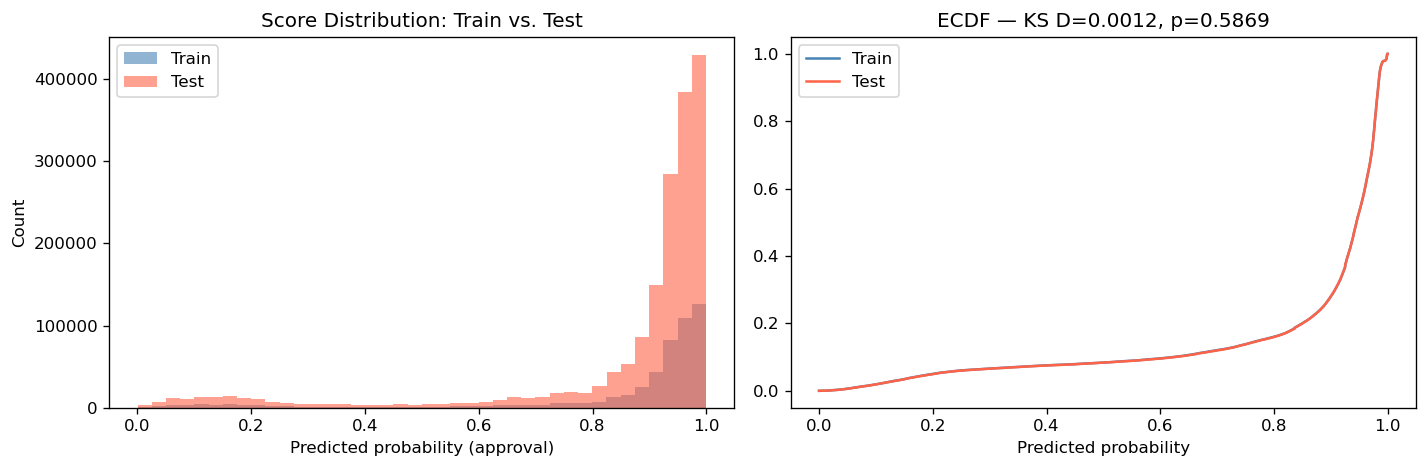

Score PSI: 0.0000 → STABLE
Score KS:  D=0.0012, p=0.5869


In [7]:
train_probs = model.predict_proba(X_train_filled)[:, 1]
test_probs  = model.predict_proba(X_test_filled)[:, 1]

score_ks_stat, score_ks_pval = ks_2samp(train_probs, test_probs)
score_psi = compute_psi(train_probs, test_probs, bins=10)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train_probs, bins=40, alpha=0.6, color='steelblue', label='Train')
axes[0].hist(test_probs,  bins=40, alpha=0.6, color='tomato',    label='Test')
axes[0].set_xlabel('Predicted probability (approval)')
axes[0].set_ylabel('Count')
axes[0].set_title('Score Distribution: Train vs. Test')
axes[0].legend()

# ECDF
for probs, label, color in [(train_probs, 'Train', 'steelblue'), (test_probs, 'Test', 'tomato')]:
    sorted_p = np.sort(probs)
    cdf = np.arange(1, len(sorted_p) + 1) / len(sorted_p)
    axes[1].plot(sorted_p, cdf, label=label, color=color)
axes[1].set_xlabel('Predicted probability')
axes[1].set_title(f'ECDF — KS D={score_ks_stat:.4f}, p={score_ks_pval:.4f}')
axes[1].legend()

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'A4_score_distribution.png'))
plt.show()

print(f'Score PSI: {score_psi:.4f} → {psi_flag(score_psi)}')
print(f'Score KS:  D={score_ks_stat:.4f}, p={score_ks_pval:.4f}')

### A5. Drift Type Diagnosis

| Shift Type | P(X) | P(Y\|X) | Remedy |
|---|---|---|---|
| Covariate shift | Changes | Stable | Importance weighting |
| Label shift | Stable | Stable | Threshold recalibration |
| Concept drift | Any | Changes | Retraining / online learning |
| Sample selection bias | Biased | Stable | Collect representative data |

In [8]:
feature_drift    = (psi_df['status'] != 'STABLE').any()
label_rate_train = y_train.mean()
label_rate_test  = y_test.mean()
label_shift      = abs(label_rate_train - label_rate_test) > 0.02

print('── Drift Type Diagnosis ──')
print(f'Feature distribution shift (PSI): {"YES" if feature_drift else "NO"}')
print(f'Label rate — Train: {label_rate_train:.3f} | Test: {label_rate_test:.3f}')
print(f'Label shift (>2pp delta):          {"YES" if label_shift else "NO"}')
print()

if feature_drift and not label_shift:
    print('DIAGNOSIS: Covariate shift — P(X) changed, P(Y|X) likely stable.')
    print('REMEDY: Importance weighting; monitor with rolling AUC.')
elif label_shift and not feature_drift:
    print('DIAGNOSIS: Label/prior shift — P(Y) changed, P(X|Y) likely stable.')
    print('REMEDY: Threshold recalibration.')
elif feature_drift and label_shift:
    print('DIAGNOSIS: Dataset shift — both P(X) and P(Y) have changed.')
    print('REMEDY: Investigate concept drift; consider retraining.')
else:
    print('DIAGNOSIS: No significant drift detected.')
    print('ACTION: Continue monitoring with PSI monthly.')

── Drift Type Diagnosis ──
Feature distribution shift (PSI): NO
Label rate — Train: 0.757 | Test: 0.757
Label shift (>2pp delta):          NO

DIAGNOSIS: No significant drift detected.
ACTION: Continue monitoring with PSI monthly.


---
## Part B: Generalization Gap & Spurious Correlations

> $$G_{\text{gap}}(\hat{h}) = R_{\text{true}}(\hat{h}) - R_{\text{emp}}(\hat{h})$$
> A large gap means in-training performance **cannot be trusted in deployment**.

### B1. Train vs. Test Performance Gap

In [9]:
train_prob = model.predict_proba(X_train_filled)[:, 1]
test_prob  = model.predict_proba(X_test_filled)[:, 1]
train_pred = model.predict(X_train_filled)
test_pred  = model.predict(X_test_filled)

perf_rows = []
for name, y_true, y_prob, y_pred in [
    ('Train (R_emp)',  y_train, train_prob, train_pred),
    ('Test  (R_true)', y_test,  test_prob,  test_pred)
]:
    perf_rows.append({
        'Split':    name,
        'AUC':      round(roc_auc_score(y_true, y_prob), 4),
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'F1':       round(f1_score(y_true, y_pred), 4),
        'Log Loss': round(log_loss(y_true, y_prob), 4),
        'Brier':    round(brier_score_loss(y_true, y_prob), 4),
    })

perf_df = pd.DataFrame(perf_rows).set_index('Split')
gap_row  = perf_df.loc['Test  (R_true)'] - perf_df.loc['Train (R_emp)']
gap_row.name = 'G_gap (Test - Train)'
perf_df = pd.concat([perf_df, gap_row.to_frame().T])

print('── Generalization Gap Table ──')
print(perf_df.to_string())
print()
print('Large negative G_gap on AUC → overfitting')
print('Near-zero G_gap → good generalization')

── Generalization Gap Table ──
                         AUC  Accuracy      F1  Log Loss   Brier
Train (R_emp)         0.8440    0.8283  0.8974    0.4434  0.1343
Test  (R_true)        0.8424    0.8276  0.8970    0.4459  0.1350
G_gap (Test - Train) -0.0016   -0.0007 -0.0004    0.0025  0.0007

Large negative G_gap on AUC → overfitting
Near-zero G_gap → good generalization


train_prob = model.predict_proba(X_train_filled)[:, 1]
test_prob  = model.predict_proba(X_test_filled)[:, 1]
train_pred = apply_threshold_policy(train_prob, prot_train['derived_race'], THRESHOLD, GROUP_THRESHOLDS)
test_pred  = apply_threshold_policy(test_prob, prot_test['derived_race'], THRESHOLD, GROUP_THRESHOLDS)

perf_rows = []
for name, y_true, y_prob, y_pred in [
    ('Train (policy)', y_train, train_prob, train_pred),
    ('Test  (policy)', y_test, test_prob, test_pred),
]:
    perf_rows.append({
        'Split': name,
        'AUC': round(roc_auc_score(y_true, y_prob), 4),
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'F1': round(f1_score(y_true, y_pred), 4),
        'F1 Denial': round(f1_score(y_true, y_pred, pos_label=0), 4),
        'Log Loss': round(log_loss(y_true, y_prob), 4),
        'Brier': round(brier_score_loss(y_true, y_prob), 4),
    })

perf_df = pd.DataFrame(perf_rows).set_index('Split')
gap_row = perf_df.loc['Test  (policy)'] - perf_df.loc['Train (policy)']
gap_row.name = 'G_gap (Test - Train)'
perf_df = pd.concat([perf_df, gap_row.to_frame().T])
print('── Generalization Gap Table ──')
print(perf_df.to_string())

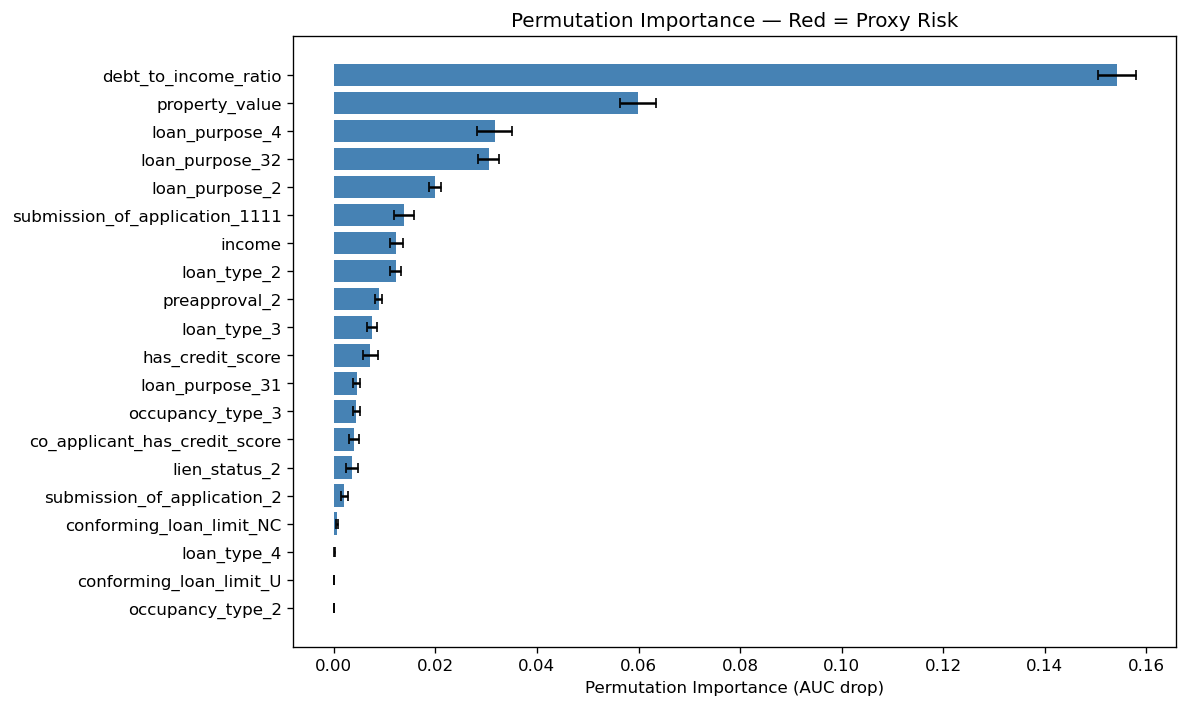

No geographic proxy features detected in top importance scores.


In [10]:
# Subsample X_test for permutation importance — avoids memory issues
np.random.seed(42)
perm_sample_idx = np.random.choice(len(X_test_filled), min(5000, len(X_test_filled)), replace=False)
X_perm_sample   = X_test_filled.iloc[perm_sample_idx]
y_perm_sample   = y_test.iloc[perm_sample_idx]

perm_result = permutation_importance(
    model, X_perm_sample, y_perm_sample,
    n_repeats=5, random_state=42, scoring='roc_auc', n_jobs=1
)

perm_df = pd.DataFrame({
    'feature':    X_test.columns,
    'importance': perm_result.importances_mean,
    'std':        perm_result.importances_std
}).sort_values('importance', ascending=False)

PROXY_FLAGS = ['census_tract', 'tract_', 'county_code', 'msa_md', 'state_code', 'zip', 'geo']
perm_df['proxy_risk'] = perm_df['feature'].apply(
    lambda f: 'FLAG' if any(p in f.lower() for p in PROXY_FLAGS) else ''
)

fig, ax = plt.subplots(figsize=(10, 6))
top20  = perm_df.head(20)
colors = ['crimson' if r == 'FLAG' else 'steelblue' for r in top20['proxy_risk']]
ax.barh(top20['feature'], top20['importance'], xerr=top20['std'], color=colors, capsize=3)
ax.set_xlabel('Permutation Importance (AUC drop)')
ax.set_title('Permutation Importance — Red = Proxy Risk')
ax.invert_yaxis()
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'B2_permutation_importance.png'))
plt.show()

flagged = perm_df[perm_df['proxy_risk'] == 'FLAG']
if not flagged.empty:
    print('\n── Flagged Proxy Features ──')
    print(flagged[['feature', 'importance']].to_string(index=False))
    print('\nGovernance note: may encode race via geographic redlining')
else:
    print('No geographic proxy features detected in top importance scores.')

### B3. Shortcut Learning Check — Counterfactual Swaps

In [11]:
PROTECTED_KEYWORDS = ['race', 'sex', 'ethnicity', 'gender']
cf_candidates = [
    c for c in X_test.columns
    if any(kw in c.lower() for kw in PROTECTED_KEYWORDS)
]

if cf_candidates:
    print(f'WARNING: Protected-attribute columns found in X: {cf_candidates}')
    baseline_probs = model.predict_proba(X_test_filled)[:, 1].mean()
    for col in cf_candidates:
        X_swapped = X_test_filled.copy()
        X_swapped[col] = 1 - X_swapped[col].clip(0, 1)
        swapped_probs = model.predict_proba(X_swapped)[:, 1].mean()
        delta = swapped_probs - baseline_probs
        print(f'  {col}: baseline={baseline_probs:.4f}, swapped={swapped_probs:.4f}, delta={delta:+.4f}')
    print('\nNon-zero delta = shortcut learning')
else:
    print('No protected-attribute columns in X_test — correctly excluded.')
    print('Shortcut check via permutation importance (B2) is the appropriate diagnostic.')

No protected-attribute columns in X_test — correctly excluded.
Shortcut check via permutation importance (B2) is the appropriate diagnostic.


---
## Part C: Robustness & Stress Testing

> **Definition:** A model is **robust** if its performance degrades *gracefully* — not catastrophically — under perturbation, shift, or adversarial inputs.

### C1. Slice-Based Evaluation

$$\mathcal{S}_k = \{(x,y) \in \mathcal{D}_{\text{eval}} : \phi_k(x) = \top\}$$

> **Red flag:** A slice accounting for 5% of the population but 30% of the losses is a governance priority, not a statistical footnote.

In [12]:
def slice_metrics(y_true, y_pred_prob, y_pred, group_series, min_n=30):
    y_true_bool = y_true.astype(bool)
    results = []
    for group in group_series.fillna('Unknown').astype(str).unique():
        mask = (group_series.fillna('Unknown').astype(str) == group).values
        n = mask.sum()
        if n < min_n:
            continue
        yt = y_true.values[mask]
        yp = y_pred_prob[mask]
        ypb = y_pred[mask]
        ytb = y_true_bool.values[mask]
        if len(np.unique(yt)) < 2:
            continue
        fp = (ypb.astype(bool) & ~ytb).sum()
        tn = (~ypb.astype(bool) & ~ytb).sum()
        fn = (~ypb.astype(bool) & ytb).sum()
        tp = (ypb.astype(bool) & ytb).sum()
        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
        results.append({
            'group': group,
            'n': n,
            'pct_of_data': round(n / len(y_true) * 100, 1),
            'approval_rate': round(yt.mean(), 4),
            'AUC': round(roc_auc_score(yt, yp), 4),
            'F1': round(f1_score(yt, ypb), 4),
            'FPR': round(fpr, 4),
            'FNR': round(fnr, 4),
            'Brier': round(brier_score_loss(yt, yp), 4),
        })
    return pd.DataFrame(results).set_index('group').sort_values('AUC')

y_pred_prob = model.predict_proba(X_test_filled)[:, 1]
y_pred = apply_threshold_policy(y_pred_prob, prot_test['derived_race'], THRESHOLD, GROUP_THRESHOLDS)

slice_cols = ['derived_race', 'derived_sex', 'derived_ethnicity']
slice_results = {}
for col in slice_cols:
    if col not in prot_test.columns:
        continue
    df = slice_metrics(y_test, y_pred_prob, y_pred, prot_test[col])
    slice_results[col] = df
    df.to_csv(os.path.join(TABLES_DIR, f'06_slice_{col}.csv'))
    print(f'── Slice: {col} ──')
    print(df.to_string())

── Slice: derived_race ──
                                                 n  pct_of_data  approval_rate     AUC      F1     FPR     FNR   Brier
group                                                                                                                 
Black or African American                   152065          8.8         0.6346  0.8310  0.8458  0.5379  0.0404  0.1917
Joint                                        37803          2.2         0.8029  0.8382  0.9185  0.6468  0.0157  0.1224
White                                      1109449         64.0         0.7820  0.8386  0.9125  0.5632  0.0292  0.1234
Race Not Available                          306591         17.7         0.7218  0.8452  0.8903  0.5600  0.0246  0.1551
American Indian or Alaska Native             12716          0.7         0.6286  0.8477  0.8477  0.5259  0.0357  0.1892
Native Hawaiian or Other Pacific Islander     4224          0.2         0.6143  0.8529  0.8446  0.4856  0.0462  0.1859
2 or more minority rac

── Slice: derived_sex ──
                        n  pct_of_data  approval_rate     AUC      F1     FPR     FNR   Brier
group                                                                                        
Joint              601023         34.7         0.8168  0.8324  0.9252  0.6257  0.0184  0.1124
Sex Not Available  155102          9.0         0.7327  0.8369  0.8920  0.5807  0.0243  0.1554
Male               586704         33.9         0.7355  0.8377  0.8932  0.5488  0.0338  0.1453
Female             389526         22.5         0.7074  0.8504  0.8876  0.4938  0.0392  0.1465


── Slice: derived_ethnicity ──
                               n  pct_of_data  approval_rate     AUC      F1     FPR     FNR   Brier
group                                                                                               
Not Hispanic or Latino   1192230         68.8         0.7736  0.8414  0.9094  0.5605  0.0293  0.1272
Ethnicity Not Available   283008         16.3         0.7289  0.8425  0.8922  0.5689  0.0242  0.1535
Joint                      44743          2.6         0.7906  0.8453  0.9152  0.6217  0.0176  0.1257
Hispanic or Latino        211621         12.2         0.6962  0.8485  0.8827  0.5208  0.0304  0.1566
Free Form Text Only          753          0.0         0.4954  0.8719  0.8094  0.4158  0.0322  0.2117


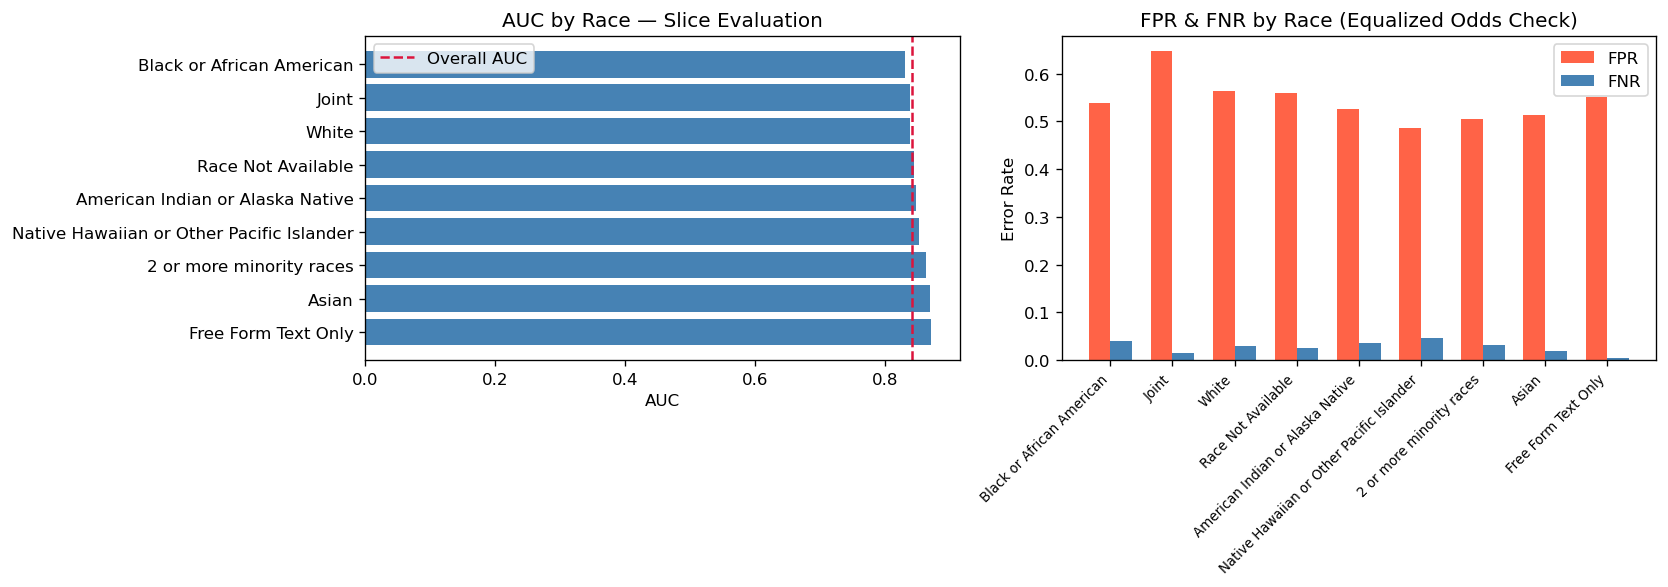

In [13]:
if 'derived_race' in slice_results:
    race_df = slice_results['derived_race'].reset_index()
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].barh(race_df['group'], race_df['AUC'], color='steelblue')
    axes[0].axvline(roc_auc_score(y_test, y_pred_prob), color='crimson',
                   linestyle='--', label='Overall AUC')
    axes[0].set_xlabel('AUC')
    axes[0].set_title('AUC by Race — Slice Evaluation')
    axes[0].legend()
    axes[0].invert_yaxis()

    x = np.arange(len(race_df))
    width = 0.35
    axes[1].bar(x - width/2, race_df['FPR'], width, label='FPR', color='tomato')
    axes[1].bar(x + width/2, race_df['FNR'], width, label='FNR', color='steelblue')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(race_df['group'], rotation=45, ha='right', fontsize=8)
    axes[1].set_ylabel('Error Rate')
    axes[1].set_title('FPR & FNR by Race (Equalized Odds Check)')
    axes[1].legend()

    plt.tight_layout()
    fig.savefig(os.path.join(FIGURES_DIR, 'C1_slice_race.png'))
    plt.show()

### C2. Macroeconomic Scenario Stress Testing

HMDA analog of DFAST-style validation.

In [14]:
scenarios = {
    'Baseline': X_test_filled.copy(),
    'Income shock -20%': X_test_filled.copy(),
    'Property value -20%': X_test_filled.copy(),
    'DTI +10 points': X_test_filled.copy(),
    'Loan amount +15%': X_test_filled.copy(),
    'Combined adverse': X_test_filled.copy(),
}

if 'income' in X_test_filled.columns:
    scenarios['Income shock -20%']['income'] = X_test_filled['income'] * 0.80
if 'property_value' in X_test_filled.columns:
    scenarios['Property value -20%']['property_value'] = X_test_filled['property_value'] * 0.80
if 'debt_to_income_ratio' in X_test_filled.columns:
    scenarios['DTI +10 points']['debt_to_income_ratio'] = X_test_filled['debt_to_income_ratio'] + 10
if 'loan_amount' in X_test_filled.columns:
    scenarios['Loan amount +15%']['loan_amount'] = X_test_filled['loan_amount'] * 1.15

X_c = X_test_filled.copy()
if 'income' in X_c:
    X_c['income'] = X_c['income'] * 0.80
if 'property_value' in X_c:
    X_c['property_value'] = X_c['property_value'] * 0.80
if 'debt_to_income_ratio' in X_c:
    X_c['debt_to_income_ratio'] = X_c['debt_to_income_ratio'] + 10
scenarios['Combined adverse'] = X_c

baseline_prob = model.predict_proba(scenarios['Baseline'])[:, 1]
baseline_policy = apply_threshold_policy(baseline_prob, prot_test['derived_race'], THRESHOLD, GROUP_THRESHOLDS)

stress_rows = []
for scenario_name, X_s in scenarios.items():
    probs = model.predict_proba(X_s)[:, 1]
    preds = apply_threshold_policy(probs, prot_test['derived_race'], THRESHOLD, GROUP_THRESHOLDS)
    mean_score = probs.mean()
    approval_rate = preds.mean()
    stress_rows.append({
        'Scenario': scenario_name,
        'Mean Score': round(mean_score, 4),
        'Policy Approval Rate': round(approval_rate, 4),
        'Delta Score vs Base': round(mean_score - baseline_prob.mean(), 4),
        'Delta Approval Rate vs Base': round(approval_rate - baseline_policy.mean(), 4),
    })

stress_df = pd.DataFrame(stress_rows).set_index('Scenario')
stress_df.to_csv(os.path.join(TABLES_DIR, '06_stress_scenarios.csv'))
print('── Stress Test Results ──')
print(stress_df.to_string())
print('Interpretation: scenario stress is a sensitivity audit, not a relabeled performance benchmark.')

── Stress Test Results ──
                     Mean Score  Policy Approval Rate  Delta Score vs Base  Delta Approval Rate vs Base
Scenario                                                                                               
Baseline                 0.8628                0.8710               0.0000                       0.0000
Income shock -20%        0.8591                0.8681              -0.0037                      -0.0029
Property value -20%      0.8598                0.8705              -0.0030                      -0.0005
DTI +10 points           0.7799                0.7461              -0.0829                      -0.1249
Loan amount +15%         0.8628                0.8710               0.0000                       0.0000
Combined adverse         0.7706                0.7349              -0.0922                      -0.1362
Interpretation: scenario stress is a sensitivity audit, not a relabeled performance benchmark.


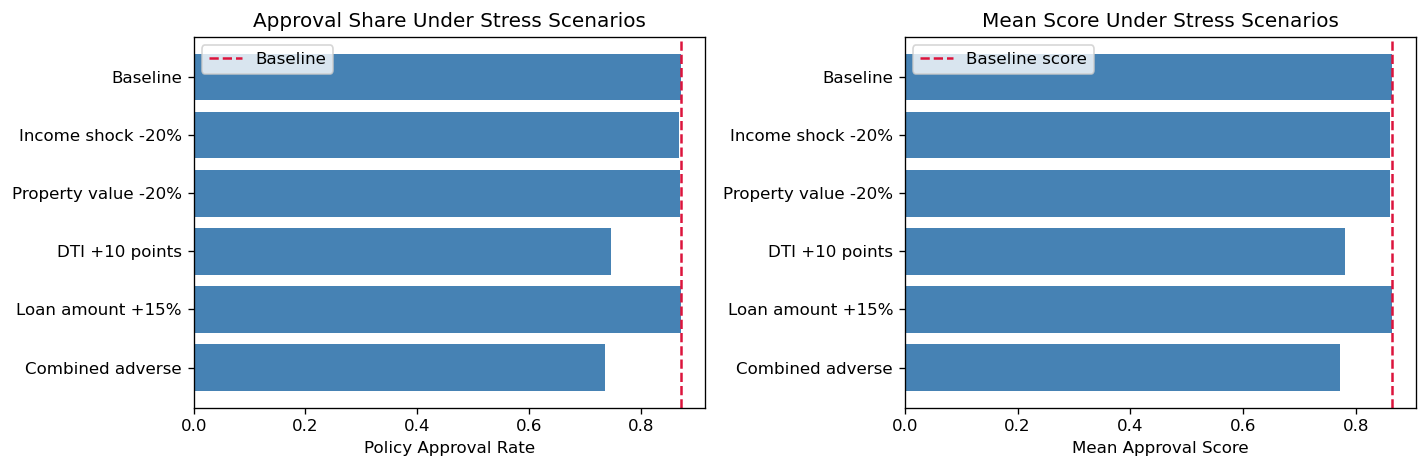

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
stress_plot = stress_df.reset_index()

axes[0].barh(stress_plot['Scenario'], stress_plot['Policy Approval Rate'], color='steelblue')
axes[0].axvline(stress_plot['Policy Approval Rate'].iloc[0], color='crimson', linestyle='--', label='Baseline')
axes[0].set_xlabel('Policy Approval Rate')
axes[0].set_title('Approval Share Under Stress Scenarios')
axes[0].legend()
axes[0].invert_yaxis()

axes[1].barh(stress_plot['Scenario'], stress_plot['Mean Score'], color='steelblue')
axes[1].axvline(stress_plot['Mean Score'].iloc[0], color='crimson', linestyle='--', label='Baseline score')
axes[1].set_xlabel('Mean Approval Score')
axes[1].set_title('Mean Score Under Stress Scenarios')
axes[1].legend()
axes[1].invert_yaxis()

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'C2_stress_scenarios.png'))
plt.show()

### C3. ICE Curves & Sensitivity Analysis

ICE reveals **heterogeneous effects**.
Sensitivity index: $V_j = \text{Var}_{x_j}[\mathbb{E}_{x_{-j}}[\hat{f}(X)]]$ — high $V_j$ with low domain justification → spurious reliance (eq. 6.2).

ICE features selected: ['debt_to_income_ratio', 'property_value', 'income']


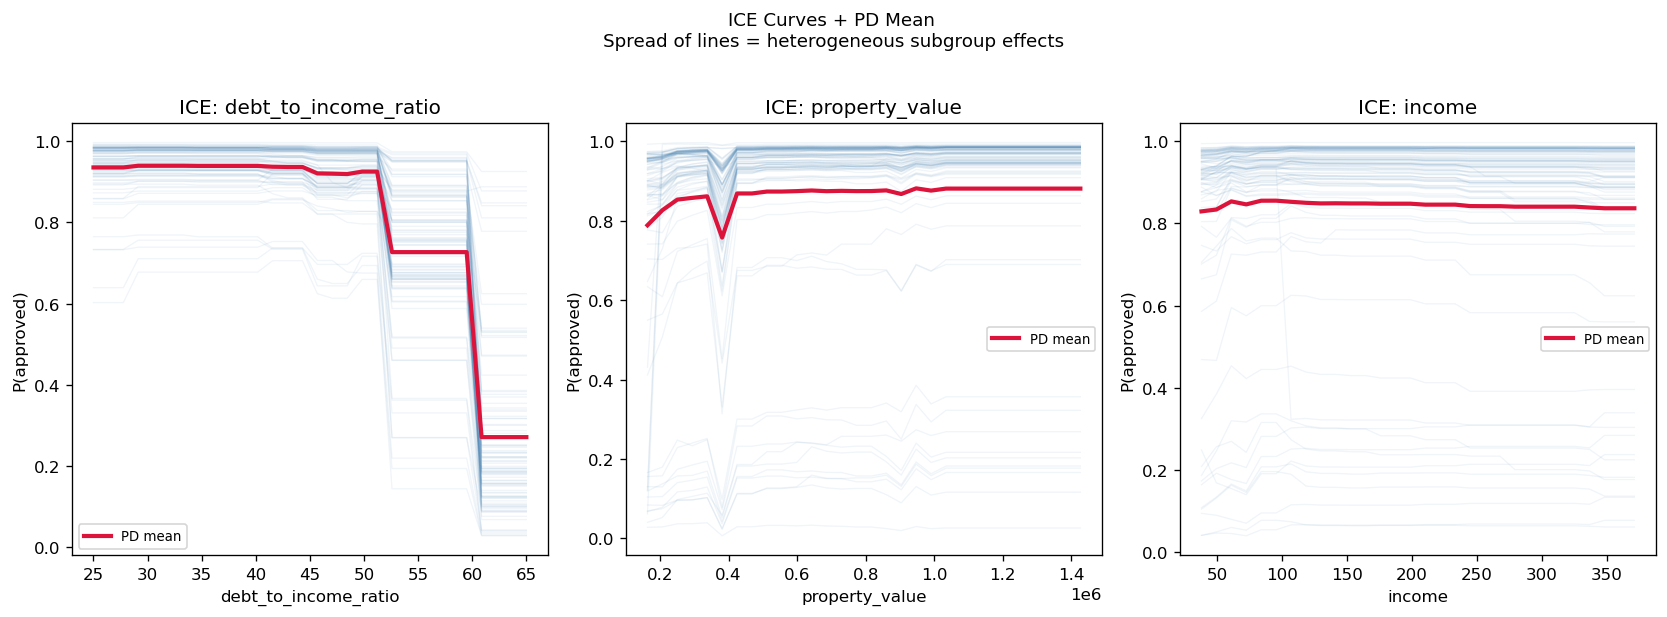

In [16]:
# ── Manual ICE plots — works with any model including Pipeline ────────────────
np.random.seed(42)
ice_sample_idx = np.random.choice(len(X_test_filled), min(100, len(X_test_filled)), replace=False)
X_ice_sample   = X_test_filled.iloc[ice_sample_idx].reset_index(drop=True)

# Only use continuous numeric features for ICE — skip booleans (get_dummies output)
# Boolean/binary features don't have meaningful gradients for ICE curves
candidate_features = [
    f for f in perm_df['feature'].head(10).tolist()
    if X_ice_sample[f].dtype in ['float64', 'float32', 'int64', 'int32']
    and X_ice_sample[f].nunique() > 5   # skip near-binary columns
]
top_features_for_ice = candidate_features[:3]

print(f'ICE features selected: {top_features_for_ice}')

if len(top_features_for_ice) == 0:
    print('No suitable continuous features found for ICE — skipping.')
else:
    fig, axes = plt.subplots(1, len(top_features_for_ice), figsize=(14, 5))
    if len(top_features_for_ice) == 1:
        axes = [axes]

    for ax, feat in zip(axes, top_features_for_ice):
        # Convert to float to avoid boolean quantile errors
        feat_series = X_ice_sample[feat].astype(float)
        feat_vals   = np.linspace(
            feat_series.quantile(0.05),
            feat_series.quantile(0.95),
            30
        )

        ice_lines = []
        for i in range(len(X_ice_sample)):
            # Repeat instance i across 30 grid rows
            X_grid = pd.DataFrame(
                [X_ice_sample.iloc[i].values] * 30,
                columns=X_ice_sample.columns
            )
            X_grid[feat] = feat_vals
            preds = model.predict_proba(X_grid)[:, 1]
            ice_lines.append(preds)

        ice_array = np.array(ice_lines)   # (n_instances, 30)
        pd_mean   = ice_array.mean(axis=0)

        for line in ice_array:
            ax.plot(feat_vals, line, alpha=0.08, color='steelblue', linewidth=0.8)
        ax.plot(feat_vals, pd_mean, color='crimson', linewidth=2.5, label='PD mean')
        ax.set_xlabel(feat)
        ax.set_ylabel('P(approved)')
        ax.set_title(f'ICE: {feat}')
        ax.legend(fontsize=8)

    fig.suptitle(
        'ICE Curves + PD Mean \n'
        'Spread of lines = heterogeneous subgroup effects',
        fontsize=11, y=1.02
    )
    plt.tight_layout()
    fig.savefig(os.path.join(FIGURES_DIR, 'C3_ice_curves.png'), bbox_inches='tight')
    plt.show()

In [17]:
from sklearn.inspection import partial_dependence

sensitivity_rows = []
for feat in perm_df['feature'].head(10):
    try:
        pd_result = partial_dependence(
            model, X_ice_sample, features=[feat],
            kind='individual', grid_resolution=20
        )
        ice_predictions = pd_result['individual'][0]
        v_j = ice_predictions.var(axis=1).mean()
        sensitivity_rows.append({
            'feature':           feat,
            'V_j (sensitivity)': round(float(v_j), 6),
            'proxy_risk':        perm_df.loc[perm_df['feature'] == feat, 'proxy_risk'].values[0]
        })
    except Exception:
        pass

sens_df = pd.DataFrame(sensitivity_rows).sort_values('V_j (sensitivity)', ascending=False)
print('── Sensitivity Index V_j ──')
print(sens_df.to_string(index=False))
print('\nHigh V_j + low domain justification → spurious reliance → flag for MRM file')

── Sensitivity Index V_j ──
                       feature  V_j (sensitivity) proxy_risk
          debt_to_income_ratio           0.025907           
submission_of_application_1111           0.018264           
                 preapproval_2           0.013682           
                   loan_type_3           0.005180           
                   loan_type_2           0.003651           
                loan_purpose_4           0.003074           
               loan_purpose_32           0.002826           
                loan_purpose_2           0.002632           
                property_value           0.001957           
                        income           0.000896           

High V_j + low domain justification → spurious reliance → flag for MRM file


---
## Summary: Robustness Audit Report

In [18]:
summary = pd.DataFrame([
    {
        'Risk Type': 'Covariate shift',
        'Metric': 'PSI per feature',
        'What It Detects': 'Input distribution change',
        'Failure Mode': 'Out-of-distribution inference',
        'HMDA Finding': str(psi_df[psi_df['status'] != 'STABLE']['feature'].tolist() or 'None flagged'),
        'Policy Implication': 'Investigate input drift before score quality degrades',
    },
    {
        'Risk Type': 'Generalization failure',
        'Metric': 'G_gap (Test - Train)',
        'What It Detects': 'Overfitting or unstable threshold policy',
        'Failure Mode': 'Unexpected production degradation',
        'HMDA Finding': f"AUC gap = {perf_df.loc['G_gap (Test - Train)', 'AUC']:.4f}",
        'Policy Implication': 'Keep the model simple enough to audit and rerun',
    },
    {
        'Risk Type': 'Spurious correlation',
        'Metric': 'Permutation importance + proxy flag',
        'What It Detects': 'Reliance on unstable or proxy features',
        'Failure Mode': 'Correct predictions for the wrong reasons',
        'HMDA Finding': str(flagged['feature'].tolist() if not flagged.empty else 'None flagged'),
        'Policy Implication': 'Remove or justify proxy-like features',
    },
    {
        'Risk Type': 'Macroeconomic stress',
        'Metric': 'Approval-rate sensitivity under scenarios',
        'What It Detects': 'Policy sensitivity to shifts in applicant finances',
        'Failure Mode': 'Approval rates swing sharply under stress',
        'HMDA Finding': f"Combined adverse delta = {stress_df.loc['Combined adverse', 'Delta Approval Rate vs Base']:.4f}",
        'Policy Implication': 'Set explicit monitoring triggers for macro shifts',
    },
    {
        'Risk Type': 'Subgroup disparity',
        'Metric': 'Slice AIR + FNR/FPR by race/sex',
        'What It Detects': 'Unequal deployment harm across protected groups',
        'Failure Mode': 'Disparate impact and wrongful-denial concentration',
        'HMDA Finding': 'See 04_* fairness tables and 06_slice_* outputs',
        'Policy Implication': 'Monitor AIR and FNR together',
    },
    {
        'Risk Type': 'Temporal drift',
        'Metric': 'Rolling AUC and PSI',
        'What It Detects': 'Silent degradation after deployment',
        'Failure Mode': 'Model trained on 2024 conditions no longer matches reality',
        'HMDA Finding': 'Not observable yet — requires post-deployment monitoring',
        'Policy Implication': 'Monthly monitoring, quarterly fairness review, annual retrain decision',
    },
])

print('══ Governance Summary Table ══')
for _, row in summary.iterrows():
    print(f"\n▸ {row['Risk Type']}")
    print(f"  Metric:   {row['Metric']}")
    print(f"  Detects:  {row['What It Detects']}")
    print(f"  Failure:  {row['Failure Mode']}")
    print(f"  Finding:  {row['HMDA Finding']}")
    print(f"  Policy:   {row['Policy Implication']}")

summary.to_csv(os.path.join(TABLES_DIR, 'robustness_governance_summary.csv'), index=False)
print(f'Saved → {os.path.join(TABLES_DIR, "robustness_governance_summary.csv")}')

══ Governance Summary Table ══

▸ Covariate shift
  Metric:   PSI per feature
  Detects:  Input distribution change
  Failure:  Out-of-distribution inference
  Finding:  None flagged
  Policy:   Investigate input drift before score quality degrades

▸ Generalization failure
  Metric:   G_gap (Test - Train)
  Detects:  Overfitting or unstable threshold policy
  Failure:  Unexpected production degradation
  Finding:  AUC gap = -0.0016
  Policy:   Keep the model simple enough to audit and rerun

▸ Spurious correlation
  Metric:   Permutation importance + proxy flag
  Detects:  Reliance on unstable or proxy features
  Failure:  Correct predictions for the wrong reasons
  Finding:  None flagged
  Policy:   Remove or justify proxy-like features

▸ Macroeconomic stress
  Metric:   Approval-rate sensitivity under scenarios
  Detects:  Policy sensitivity to shifts in applicant finances
  Failure:  Approval rates swing sharply under stress
  Finding:  Combined adverse delta = -0.1362
  Policy:  

---
## Monitoring Stack Recommendation

A monitoring stack should include **both** leading and lagging indicators.

| Indicator | Type | Metric | Frequency | Threshold | Action |
|---|---|---|---|---|---|
| Feature PSI — income, DTI, loan_amount | Leading | PSI | Monthly | > 0.10 monitor; > 0.25 retrain | Investigate input pipeline |
| Score distribution PSI | Leading | PSI on model outputs | Monthly | > 0.10 | Check for label shift |
| Rolling AUC by race | Lagging | AUC per group | Quarterly | Drop > 0.03 | Fairness audit |
| Rolling AUC overall | Lagging | AUC overall | Monthly | Drop > 0.02 | Model review |
| 80% rule ratio by race | Lagging | AIR | Quarterly | < 0.80 | Mitigation required |

> **Core principle:** Robustness testing asks whether the model *remains reliable* as conditions change — a prerequisite for defensible deployment.